In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
cols = ['Date', 'Primary Type', 'Location Description', 'Arrest', 'District']

df = pd.read_csv("Chicago_Crimes_2012_to_2017.csv", usecols=cols)

df = df.sample(n=100000, random_state=42)

In [ ]:
df.dropna(inplace=True)

df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y %I:%M:%S %p')

df['District'] = df['District'].astype(int)
df['Arrest'] = df['Arrest'].astype(int)

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day_name()
df['Hour'] = df['Date'].dt.hour

Descriptive Analysis + Visualizations


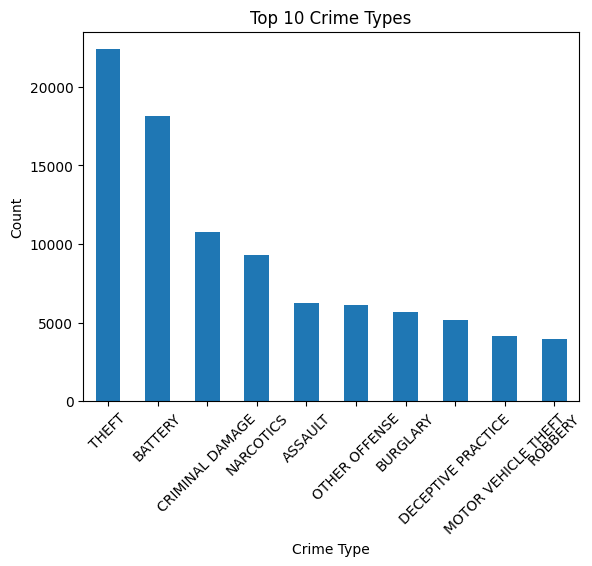

In [ ]:
#toop crime types
crime_counts = df['Primary Type'].value_counts().head(10)

crime_counts.plot(kind='bar')
plt.title("Top 10 Crime Types")
plt.xlabel("Crime Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

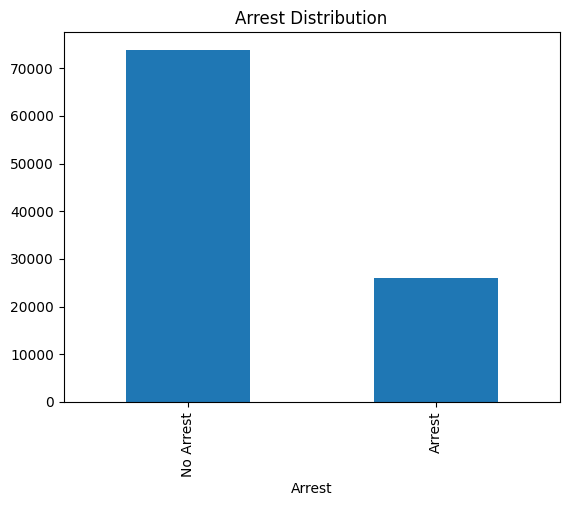

In [ ]:
#arrest dist
df['Arrest'].value_counts().plot(kind='bar')
plt.title("Arrest Distribution")
plt.xticks([0,1], ['No Arrest', 'Arrest'])
plt.show()

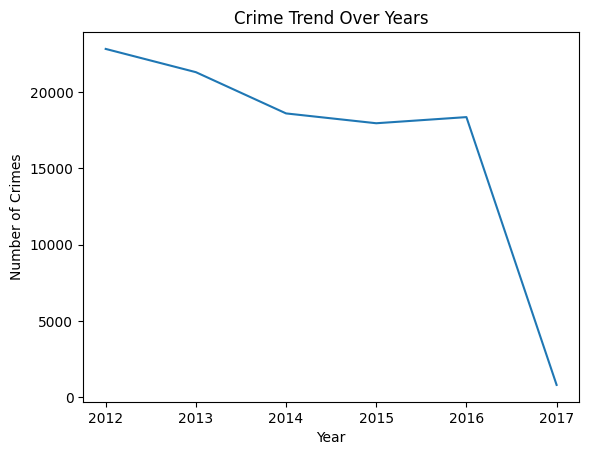

In [ ]:
#year wise trend
df['Year'].value_counts().sort_index().plot(kind='line')
plt.title("Crime Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Crimes")
plt.show()

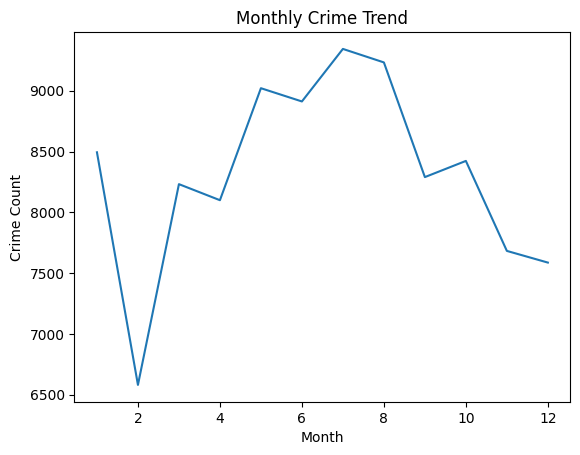

In [ ]:
#monthly trend
df['Month'].value_counts().sort_index().plot(kind='line')
plt.title("Monthly Crime Trend")
plt.xlabel("Month")
plt.ylabel("Crime Count")
plt.show()

In [ ]:
#crime type vs arrest
table = pd.crosstab(df['Primary Type'], df['Arrest'])
table

Arrest,0,1
Primary Type,,
ARSON,109,13
ASSAULT,4742,1483
BATTERY,13939,4206
BURGLARY,5419,288
CONCEALED CARRY LICENSE VIOLATION,1,7
CRIM SEXUAL ASSAULT,411,55
CRIMINAL DAMAGE,10069,694
CRIMINAL TRESPASS,756,1701
DECEPTIVE PRACTICE,4533,615


In [ ]:
#chi square
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square value:", chi2)
print("P-value:", p)

Chi-square value: 42846.11983772457
P-value: 0.0


Probability Analysis + Logistic Regression

In [ ]:
#prob of arrest
prob = df.groupby('Primary Type')['Arrest'].mean().sort_values(ascending=False)

print(prob)

Primary Type
PUBLIC INDECENCY                     1.000000
PROSTITUTION                         0.996350
NARCOTICS                            0.995268
GAMBLING                             0.986667
LIQUOR LAW VIOLATION                 0.978417
INTERFERENCE WITH PUBLIC OFFICER     0.931416
OBSCENITY                            0.923077
CONCEALED CARRY LICENSE VIOLATION    0.875000
WEAPONS VIOLATION                    0.788177
PUBLIC PEACE VIOLATION               0.752252
CRIMINAL TRESPASS                    0.692308
HOMICIDE                             0.353261
STALKING                             0.254237
SEX OFFENSE                          0.244957
ASSAULT                              0.238233
BATTERY                              0.231799
OTHER OFFENSE                        0.209344
INTIMIDATION                         0.181818
OFFENSE INVOLVING CHILDREN           0.166667
DECEPTIVE PRACTICE                   0.119464
CRIM SEXUAL ASSAULT                  0.118026
KIDNAPPING           

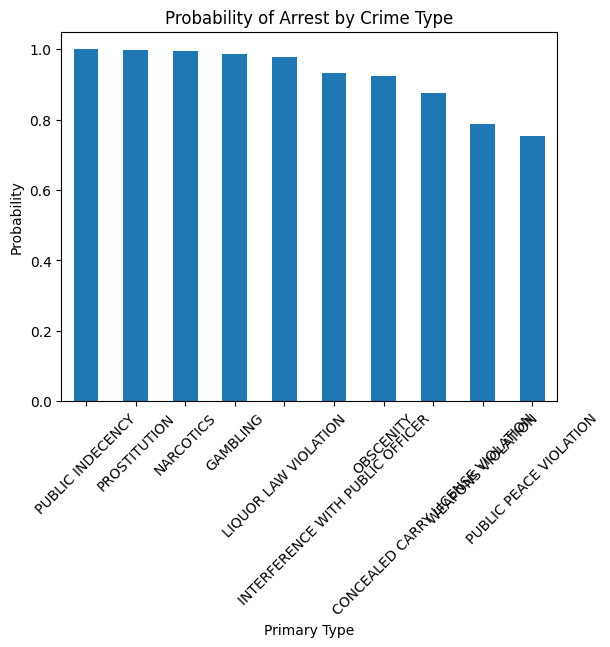

In [ ]:
#visualize prob
prob.head(10).plot(kind='bar')
plt.title("Probability of Arrest by Crime Type")
plt.ylabel("Probability")
plt.xticks(rotation=45)
plt.show()

In [ ]:
#prep data for log reg
df_model = df[['Primary Type', 'Location Description', 'Arrest']].copy()

df_model = pd.get_dummies(df_model, drop_first=True)

In [ ]:
df_model = df_model.iloc[:, :50]  # keep first 50 columns only

In [ ]:
#train model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X = df_model.drop('Arrest', axis=1)
y = df_model['Arrest']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)
print("Accuracy:", accuracy)

Accuracy: 0.8695695695695695


In [ ]:
#model interpretation
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.98      0.92     14839
           1       0.92      0.54      0.68      5141

    accuracy                           0.87     19980
   macro avg       0.89      0.76      0.80     19980
weighted avg       0.88      0.87      0.86     19980



In [ ]:
#feature imp
importance = pd.Series(model.coef_[0], index=X.columns)
importance.sort_values(ascending=False).head(10)

,0
Primary Type_NARCOTICS,5.425771
Primary Type_PROSTITUTION,4.960382
Primary Type_GAMBLING,3.687342
Primary Type_LIQUOR LAW VIOLATION,3.392421
Primary Type_INTERFERENCE WITH PUBLIC OFFICER,2.690868
Primary Type_WEAPONS VIOLATION,1.722223
Primary Type_PUBLIC PEACE VIOLATION,1.514098
Primary Type_CRIMINAL TRESPASS,1.191262
Location Description_AIRPORT TERMINAL LOWER LEVEL - NON-SECURE AREA,1.177891
Primary Type_OBSCENITY,0.827382


HEATMAP


In [ ]:
#data for heatmap
table = pd.crosstab(df['Primary Type'], df['Arrest'])

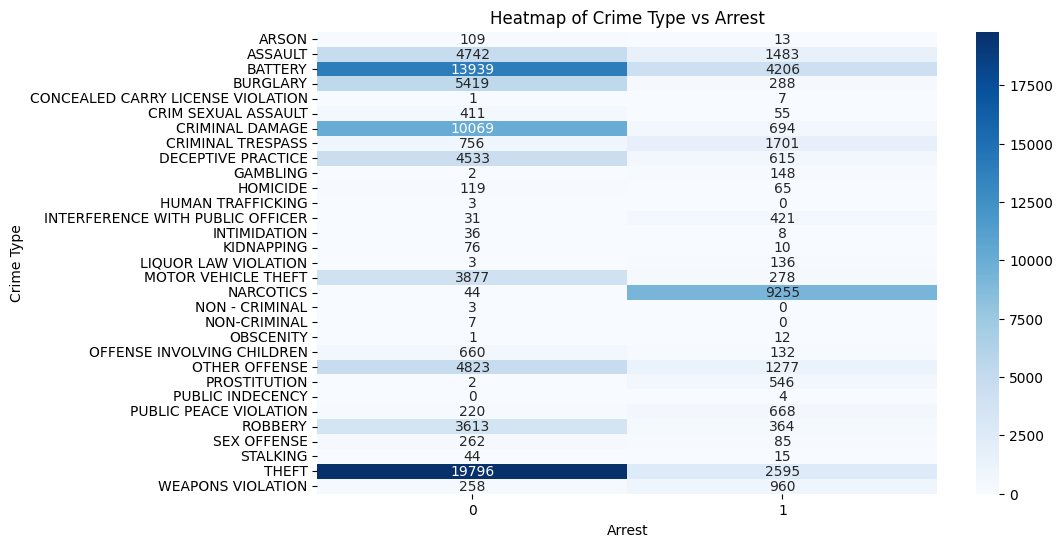

In [ ]:
#plot
plt.figure(figsize=(10,6))
sns.heatmap(table, annot=True, fmt='d', cmap='Blues')

plt.title("Heatmap of Crime Type vs Arrest")
plt.xlabel("Arrest")
plt.ylabel("Crime Type")
plt.show()

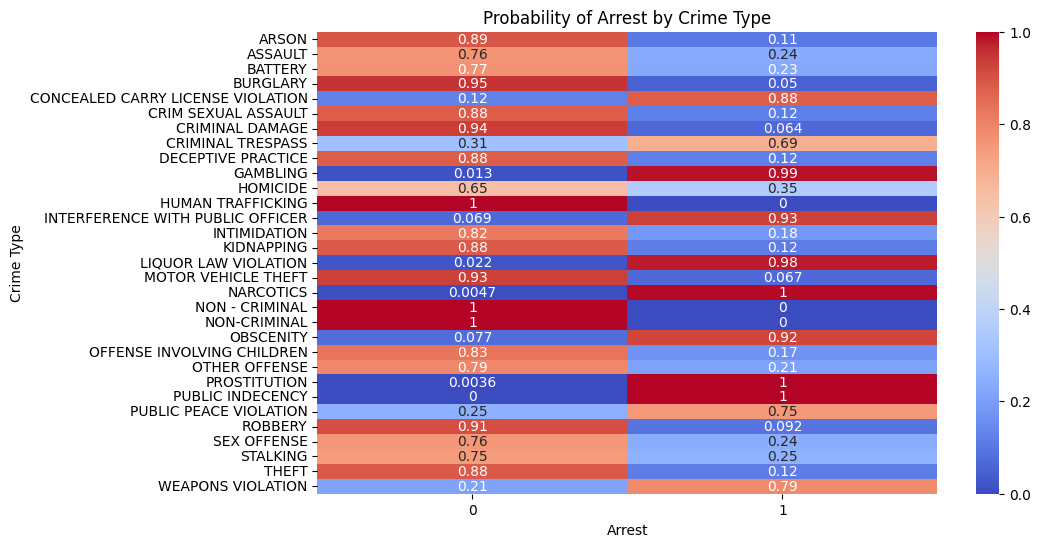

In [ ]:
#normalised heatmap
table_norm = pd.crosstab(df['Primary Type'], df['Arrest'], normalize='index')

plt.figure(figsize=(10,6))
sns.heatmap(table_norm, annot=True, cmap='coolwarm')

plt.title("Probability of Arrest by Crime Type")
plt.xlabel("Arrest")
plt.ylabel("Crime Type")
plt.show()

DONE
